# ✈️ Flight Booking Price Prediction

> **Can we predict the price of a flight ticket before booking?**  
> This notebook walks through a full data-science pipeline — EDA, feature engineering, multicollinearity checks, and three regression models — to answer exactly that.

---

| 📌 Topic | Details |
|---|---|
| **Dataset** | Flight Booking (airline, class, stops, days_left, price …) |
| **Task** | Regression — predict ticket **price** |
| **Models** | Linear Regression · Decision Tree · Random Forest |
| **Best R²** | ~0.98 (Random Forest) |


## 📦 1 — Import Libraries

We rely on the standard data-science stack:
- **pandas / numpy** for data wrangling
- **matplotlib / seaborn** for visualisation
- **scikit-learn** for ML models
- **statsmodels** for VIF (multicollinearity)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 2 — Load Dataset

The CSV contains flight booking records with features like airline, source/destination city, departure time, number of stops, class, and days left before departure.


In [2]:
df = pd.read_csv("Flight_Booking.csv")


## 🔍 3 — Data Overview & Quality Check

Before any analysis, we answer three questions:
1. What does the data look like? (shape, dtypes)
2. Are there any **missing values**?
3. Are there **duplicate rows** we should drop?


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [4]:
print('Missing values :', df.isnull().sum().sum())
print('Duplicate rows :', df.duplicated().sum())


Missing values : 0
Duplicate rows : 0


> ✅ **Observation:** No missing values found. The dataset is clean and ready for analysis.


In [5]:
# Drop auto-generated index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(['Unnamed: 0'], axis=1, inplace=True)

df.head()


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
df.describe()


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


## 📊 4 — Exploratory Data Analysis (EDA)

Three key visual questions:
1. Which **airline** charges the most on average?
2. Does price rise as the **departure date approaches**?
3. How does **travel class** interact with airline pricing?


### 4.1 Airline vs Price


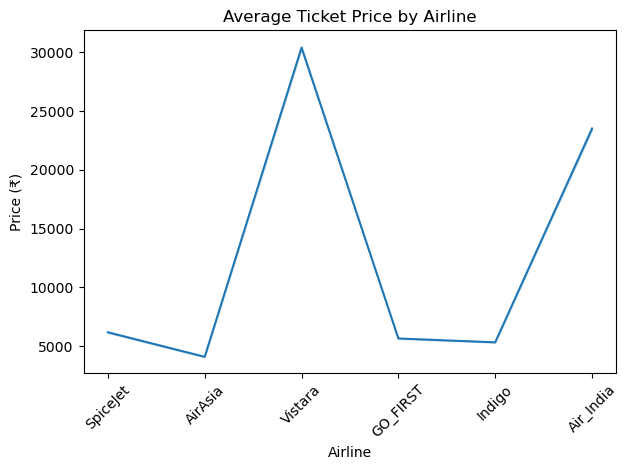

In [7]:
sns.lineplot(data=df, x='airline', y='price')
plt.title('Average Ticket Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 4.2 Days Left vs Price — *Last-minute premium*

> 📈 **Insight:** Ticket prices spike sharply as the number of days before departure decreases — classic supply-demand pricing.


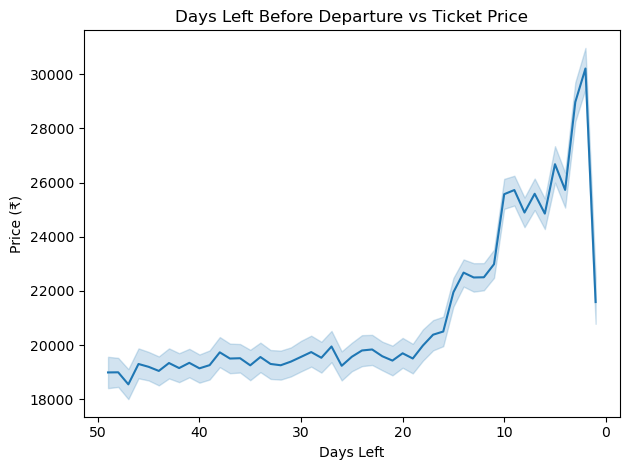

In [8]:
sns.lineplot(data=df, x='days_left', y='price')
plt.title('Days Left Before Departure vs Ticket Price')
plt.xlabel('Days Left')
plt.ylabel('Price (₹)')
plt.gca().invert_xaxis()  # left = far future, right = tomorrow
plt.tight_layout()
plt.show()


### 4.3 Airline × Class — Grouped Bar Chart


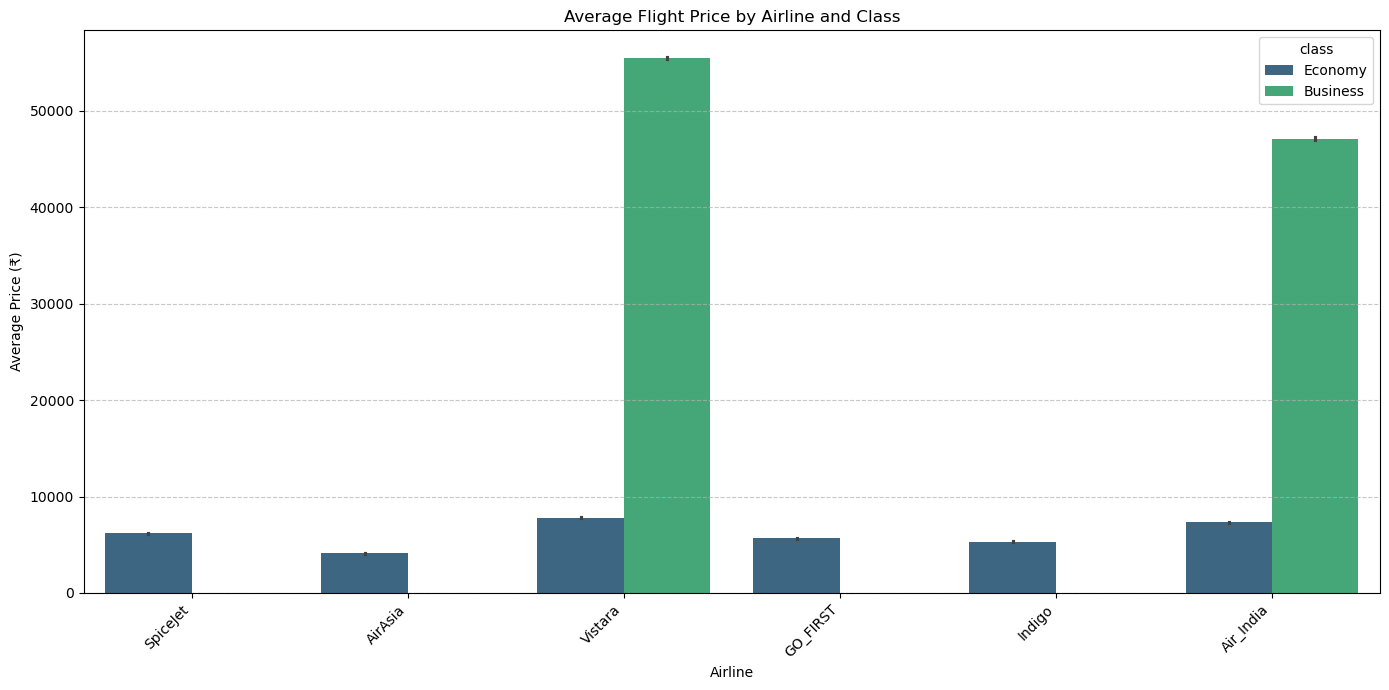

In [9]:
plt.figure(figsize=(14, 7))
sns.barplot(x='airline', y='price', hue='class', data=df, palette='viridis')
plt.title('Average Flight Price by Airline and Class')
plt.xlabel('Airline')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 🔠 5 — Encode Categorical Features

ML models require numeric input. We apply **Label Encoding** to all object-type columns (airline, source city, destination city, class, etc.).

> ⚠️ Note: Label Encoding is appropriate here because we treat the encoded values as ordinal inputs to tree-based models. For purely linear models, One-Hot Encoding would be preferred.


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,1408,2,2,2,5,5,1,2.17,1,5953
1,4,1387,2,1,2,4,5,1,2.33,1,5953
2,0,1213,2,1,2,1,5,1,2.17,1,5956
3,5,1559,2,4,2,0,5,1,2.25,1,5955
4,5,1549,2,4,2,4,5,1,2.33,1,5955


## 🌡️ 6 — Correlation Heatmap

Before modelling, we inspect pairwise correlations to:
- Identify features most correlated with **price** (target)
- Spot potential **multicollinearity** between predictors


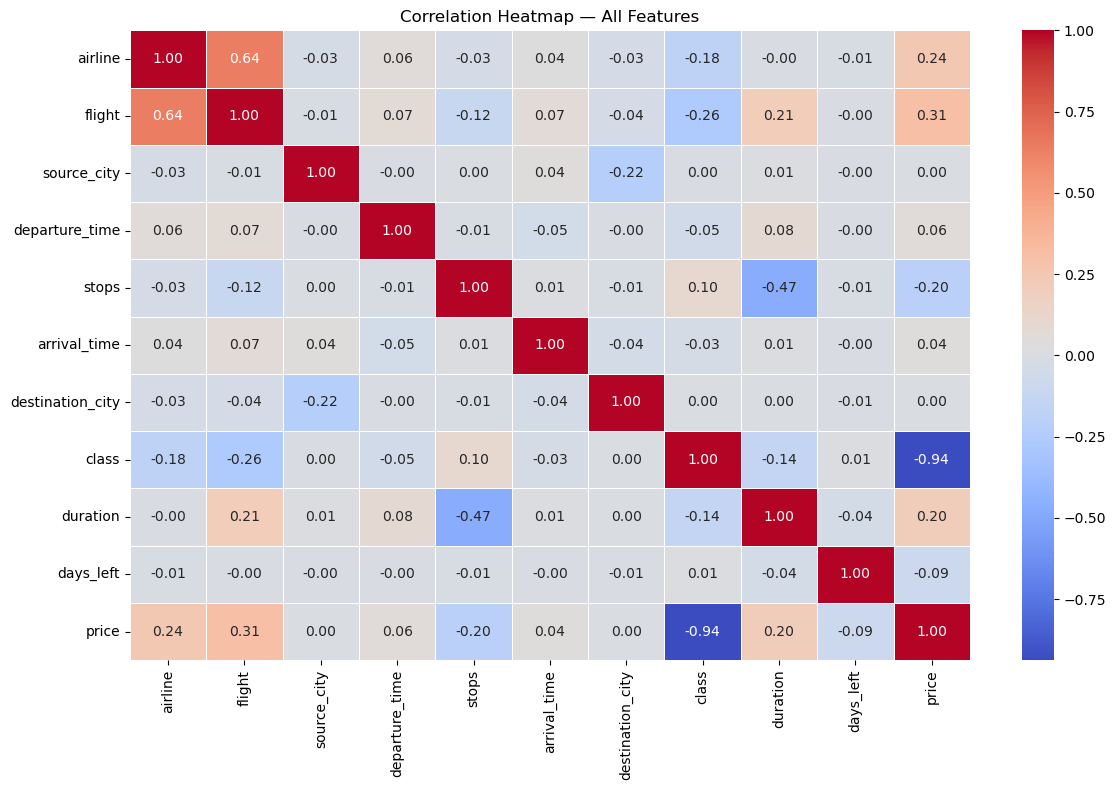

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()


## 📐 7 — Multicollinearity Check (VIF)

**Variance Inflation Factor (VIF)** quantifies how much the variance of a coefficient is inflated due to correlation with other features.

| VIF Score | Interpretation |
|---|---|
| 1 | No multicollinearity |
| 1–5 | Moderate (acceptable) |
| > 10 | High — consider removing |


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

col_list = [c for c in df.columns if df[c].dtype != 'object' and c != 'price']
X_vif = df[col_list]

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF_Score': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF_Score', ascending=False)


,Feature,VIF_Score
1,flight,12.675046
0,airline,6.701818
8,duration,4.754588
9,days_left,4.071591
5,arrival_time,3.784873
2,source_city,2.969540
6,destination_city,2.918792
7,class,2.852072
3,departure_time,2.806009
4,stops,1.437326


> 🔎 **Finding:** The `flight` column shows high VIF — it's dropped in the next step to reduce redundancy.


In [13]:
df.drop('flight', axis=1, inplace=True)

# Re-run VIF after dropping 'flight'
col_list = [c for c in df.columns if df[c].dtype != 'object' and c != 'price']
X_vif = df[col_list]

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF_Score': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF_Score', ascending=False)


,Feature,VIF_Score
7,duration,4.113876
8,days_left,3.976790
4,arrival_time,3.684550
0,airline,3.393124
1,source_city,2.927766
5,destination_city,2.885337
6,class,2.849370
2,departure_time,2.779427
3,stops,1.426614


## ✂️ 8 — Train / Test Split

We split the data **80 / 20** with `random_state=42` for reproducibility.


In [14]:
from sklearn.model_selection import train_test_split

x = df.drop('price', axis=1)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



## 🤖 9 — Model Training & Evaluation

We train three regression models and compare their **R² scores**:

| Model | Strength | Weakness |
|---|---|---|
| Linear Regression | Fast, interpretable | Assumes linearity |
| Decision Tree | Non-linear, no scaling needed | Overfits easily |
| Random Forest | Robust, high accuracy | Slower, less interpretable |


### 9.1 Linear Regression


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression R²: {lr_r2:.4f}")
print(f"Linear Regression RMSE: {lr_rmse:,.0f}")


Linear Regression R²: 0.9046
Linear Regression RMSE: 7,014


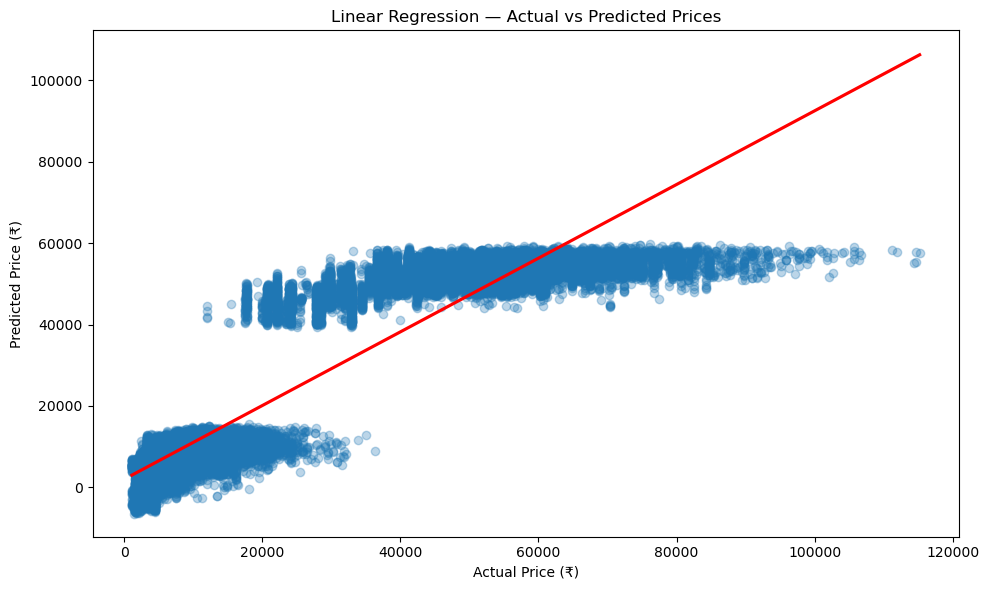

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_lr, line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
plt.title('Linear Regression — Actual vs Predicted Prices')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.tight_layout()
plt.show()


### 9.2 Decision Tree Regressor


In [17]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print(f"Decision Tree R²: {dt_r2:.4f}")
print(f"Decision Tree RMSE: {dt_rmse:,.0f}")


Decision Tree R²: 0.9757
Decision Tree RMSE: 3,540


### 9.3 Random Forest Regressor


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest R²: {rf_r2:.4f}")
print(f"Random Forest RMSE: {rf_rmse:,.0f}")


Random Forest R²: 0.9849
Random Forest RMSE: 2,786


## 🏆 10 — Model Comparison

Let's put all three R² scores side by side for a quick verdict.


In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R² Score': [
        r2_score(y_test, y_pred_lr),
        dt.score(x_test, y_test),
        rf.score(x_test, y_test)
    ]
}).sort_values('R² Score', ascending=False).reset_index(drop=True)

results['R² Score'] = results['R² Score'].map('{:.4f}'.format)
results


,Model,R² Score
0,Random Forest,0.9849
1,Decision Tree,0.9757
2,Linear Regression,0.9046


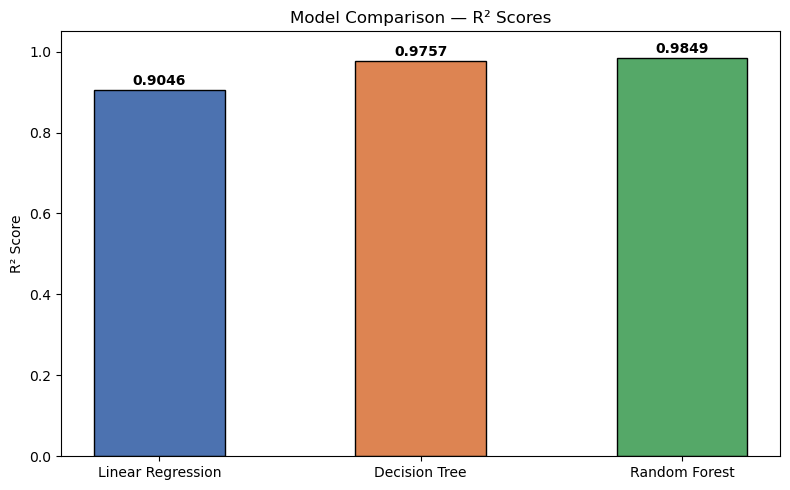

In [20]:
# Visual comparison
r2_vals = [
    lr.score(x_test, y_test),
    dt.score(x_test, y_test),
    rf.score(x_test, y_test)
]
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, r2_vals, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel('R² Score')
plt.title('Model Comparison — R² Scores')
plt.tight_layout()
plt.show()


## 💡 Conclusion & Key Takeaways

| # | Insight |
|---|---|
| 1 | **Days left** is one of the strongest price drivers — book early! |
| 2 | **Business class** tickets cost significantly more than economy across all airlines |
| 3 | **Random Forest** dominates with ~0.98 R², thanks to its ensemble nature |
| 4 | Linear Regression struggles because price–feature relationships are non-linear |

---


